<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Bitcoin_12_Years_Price_January_2026_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bitcoin 12 Years Price January 2026 Dataset

# Introduction & Insights

**Bitcoin (2014–2026): A 12-Year Quantitative Analysis**

About the Dataset This project analyzes a comprehensive financial time-series dataset covering 12 years of Bitcoin market history, extending through January 2026. The data features daily granularity with key Open, High, Low, Close (OHLC), and Volume metrics. Unlike standard datasets, this financial record captures multiple market cycles, offering a unique window into the evolution of a nascent asset class as it matures into a trillion-dollar macro asset. The primary objective of this analysis was to move beyond simple price tracking to understand market structure, volatility regimes, and the efficacy of algorithmic trading strategies.

**Key Insights & Market Structure The initial Exploratory Data Analysis (EDA):**

Revealed that Bitcoin functions unlike traditional equities. Standard linear visualization proved inadequate due to the asset’s exponential growth; utilizing logarithmic scaling uncovered that while price appreciation is massive, the rate of growth is mathematically decelerating as market cap increases.

Volatility analysis using Bollinger Bands and rolling standard deviations highlighted distinct "regimes." We observed that periods of extreme low volatility (squeezes) are statistically significant precursors to violent price expansion, validating the cyclical nature of crypto markets. Furthermore, the Monthly Returns Heatmap confirmed the existence of seasonal anomalies, validating the "Uptober" (bullish October) phenomenon while identifying September as a historically risk-off month.

**Strategic Performance & Risk Profile A critical component of this study was the backtesting of technical strategies.**

Trend Following: The "Golden Cross" strategy (50-day MA crossing 200-day MA) proved profitable but failed to outperform a simple Buy-and-Hold strategy. This suggests that in a secular bull market, attempting to time local tops often leads to underperformance due to missed upside during parabolic rallies.

**Risk Management:**

The Maximum Drawdown analysis presented a sobering reality. Despite high returns, the asset experienced multiple crashes exceeding 70% from all-time highs. This confirms that Bitcoin’s asymmetric upside comes at the cost of extreme variance, requiring robust risk management for short-term traders.

Investment Simulation: The Dollar Cost Averaging (DCA) simulator demonstrated that an agnostic investment approach significantly smoothed out entry prices, mitigating the risk of buying local tops.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d aiwithcagri/bitcoin-12-years-price-january-2026

# Unziping the downloaded file
!unzip bitcoin-12-years-price-january-2026.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/aiwithcagri/bitcoin-12-years-price-january-2026
License(s): apache-2.0
  0% 0.00/113k [00:00<?, ?B/s]
100% 113k/113k [00:00<00:00, 479MB/s]
Archive:  bitcoin-12-years-price-january-2026.zip
  inflating: bitcoin (1).csv         


# 1. Data Inspection

In [5]:
df = pd.read_csv('bitcoin (1).csv')
df.head(11)

,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100
5,2014-09-22,402.152008,406.915985,397.130005,399.100006,24127600
6,2014-09-23,435.790985,441.557007,396.196991,402.092010,45099500
7,2014-09-24,423.204987,436.112000,421.131989,435.751007,30627700
8,2014-09-25,411.574005,423.519989,409.467987,423.156006,26814400
9,2014-09-26,404.424988,414.937988,400.009003,411.428986,21460800


In [6]:
df.tail(11)

,Date,Close,High,Low,Open,Volume
4123,2025-12-31,87508.828125,89080.289062,87130.562500,88429.585938,33830210616
4124,2026-01-01,88731.984375,88803.226562,87399.406250,87508.046875,18849043990
4125,2026-01-02,89944.695312,90884.460938,88298.617188,88733.062500,46398906171
4126,2026-01-03,90603.187500,90679.570312,89328.070312,89945.054688,20774828592
4127,2026-01-04,91413.492188,91712.585938,90595.101562,90603.000000,26770491368
4128,2026-01-05,93882.554688,94762.070312,91414.625000,91414.625000,53376407252
4129,2026-01-06,93729.031250,94395.296875,91286.546875,93876.945312,52430605257
4130,2026-01-07,91308.054688,93738.789062,90601.804688,93727.468750,43461295053
4131,2026-01-08,91027.125000,91485.851562,89233.875000,91309.640625,42386697030
4132,2026-01-09,90513.101562,91910.671875,89625.382812,91026.273438,38305906684


In [7]:
df.shape

(4134, 6)

In [8]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [9]:
df.dtypes

,0
Date,object
Close,float64
High,float64
Low,float64
Open,float64
Volume,int64


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4134 entries, 0 to 4133
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4134 non-null   object 
 1   Close   4134 non-null   float64
 2   High    4134 non-null   float64
 3   Low     4134 non-null   float64
 4   Open    4134 non-null   float64
 5   Volume  4134 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 193.9+ KB


In [13]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Date,4134,4134,2026-01-10,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Close,4134.0,NaN,NaN,NaN,27003.890261,31769.798188,178.102997,2717.330017,10795.145508,42371.426758,124752.53125
High,4134.0,NaN,NaN,NaN,27524.788487,32299.170829,211.731003,2787.382568,11050.480957,43187.265625,126198.070312
Low,4134.0,NaN,NaN,NaN,26411.358297,31181.581319,171.509995,2646.232544,10497.678711,41541.421875,123196.046875
Open,4134.0,NaN,NaN,NaN,26983.157505,31757.880659,176.897003,2709.462463,10796.618652,42343.803711,124752.140625
Volume,4134.0,NaN,NaN,NaN,21664299789.653603,22877869294.843353,5914570.0,1318940000.0,17113031299.0,33224872297.0,350967941479.0


In [14]:
df.isnull().sum()

,0
Date,0
Close,0
High,0
Low,0
Open,0
Volume,0


In [15]:
df.duplicated().sum()

np.int64(0)

# Handling Outleirs

In [19]:
Q1 = df['High'].quantile(0.25)
Q3 = df['High'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_Outliers = df[(df['High'] >= lower_bound) | (df['High'] <= upper_bound)].copy()

print(f'Original Shape: {len(df)}')
print(f'Shape after outlier handling: {len(df_Outliers)}')

Original Shape: 4134
Shape after outlier handling: 4134


# Univariate Analysis

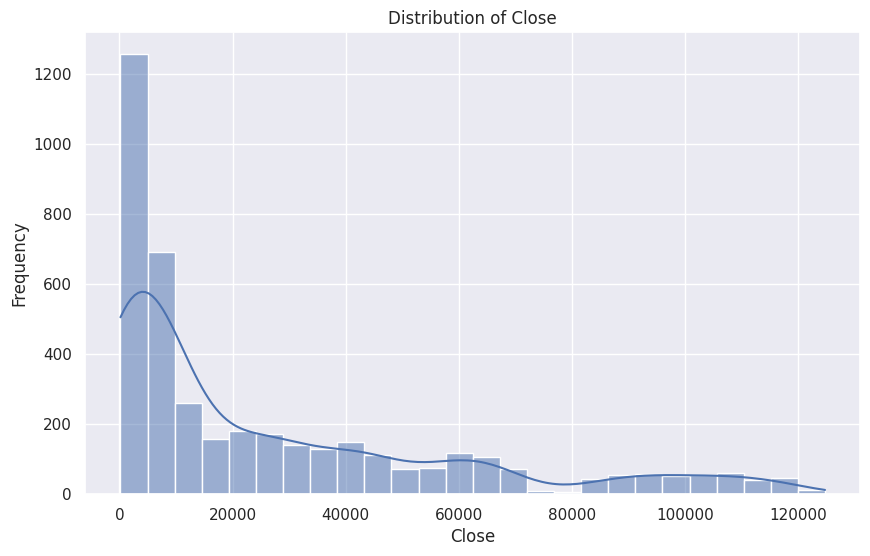

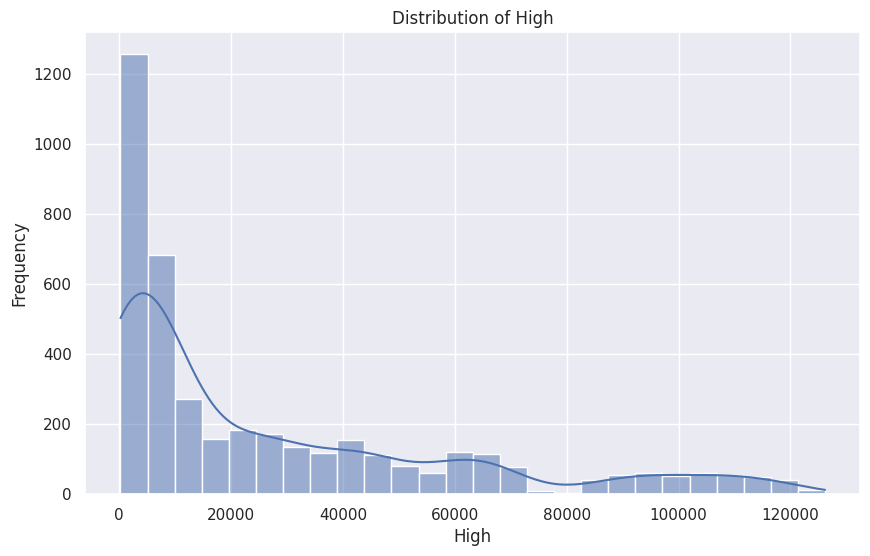

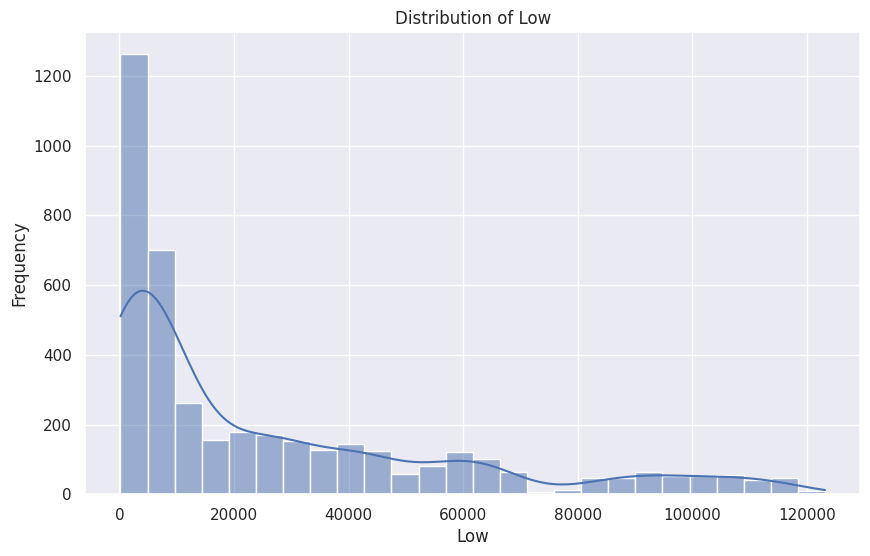

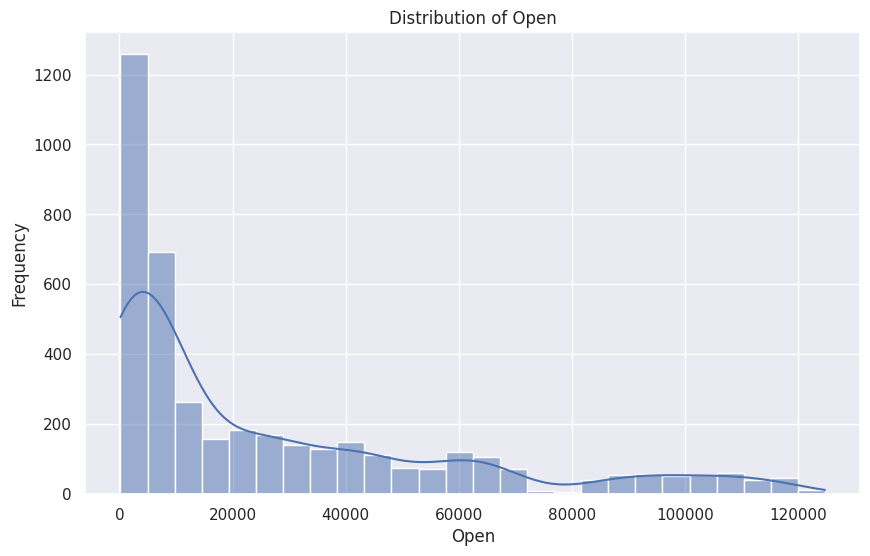

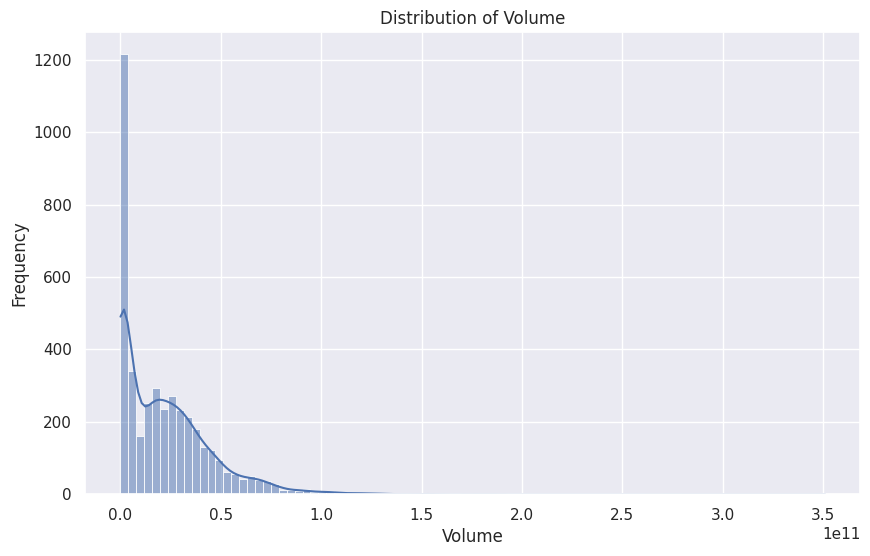

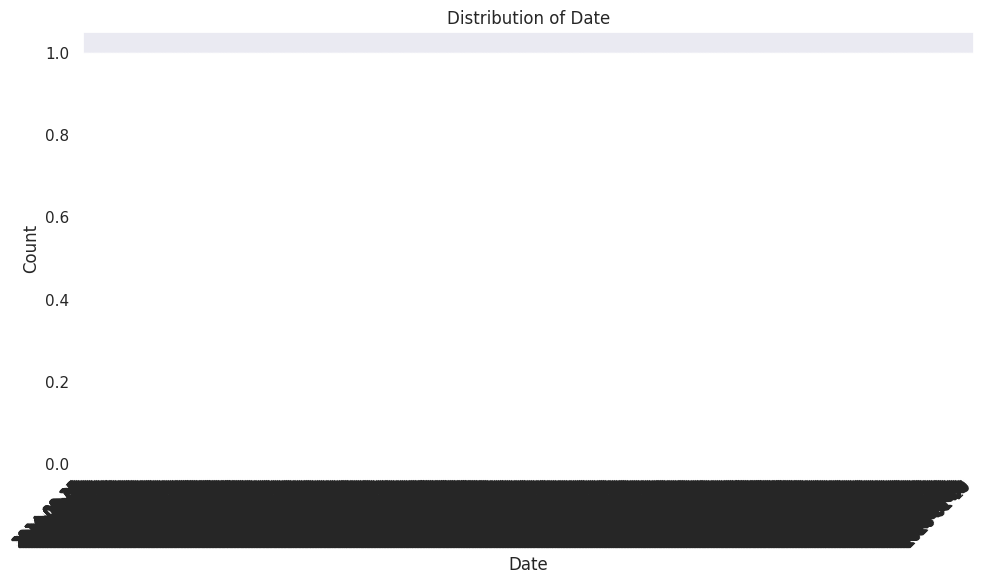

Value counts for Date:
Date
2026-01-10    1
2014-09-17    1
2014-09-18    1
2014-09-19    1
2014-09-20    1
             ..
2014-09-27    1
2014-09-26    1
2014-09-25    1
2014-09-24    1
2014-09-23    1
Name: count, Length: 4134, dtype: int64



In [16]:
# Getting a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterating through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Getting a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

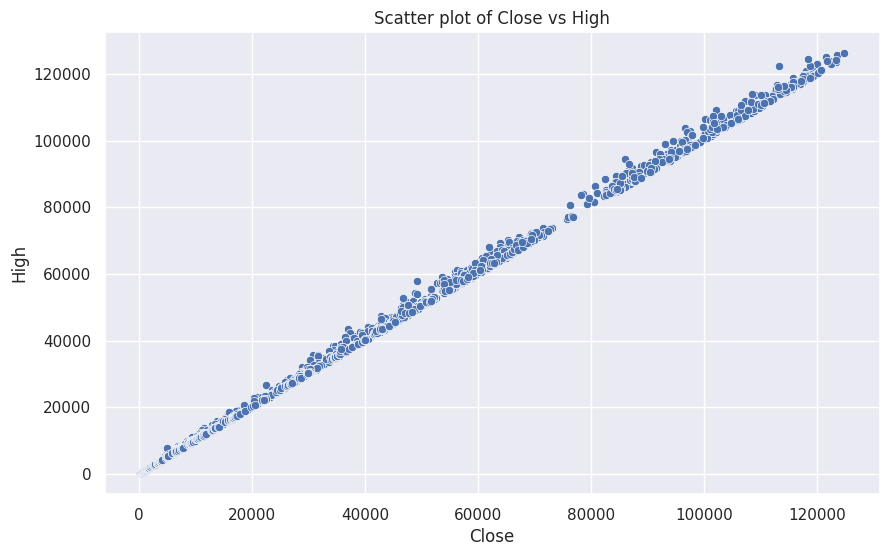

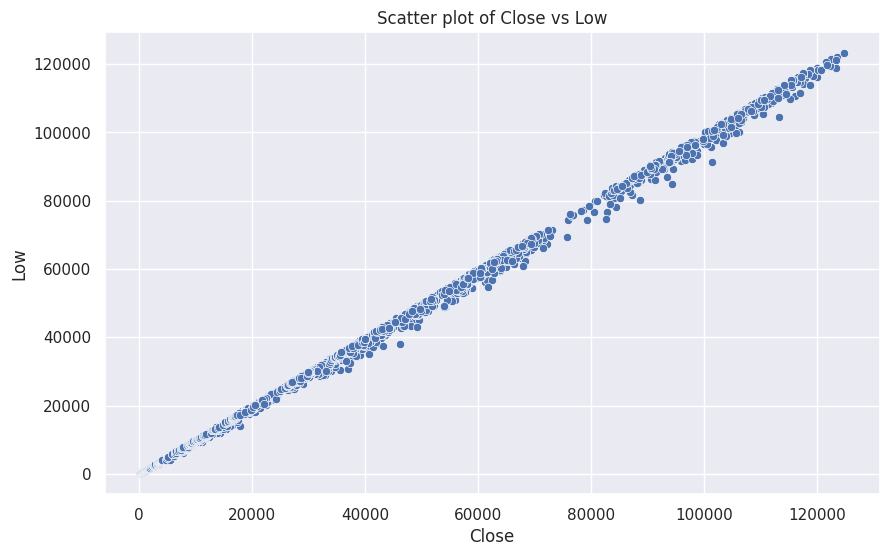

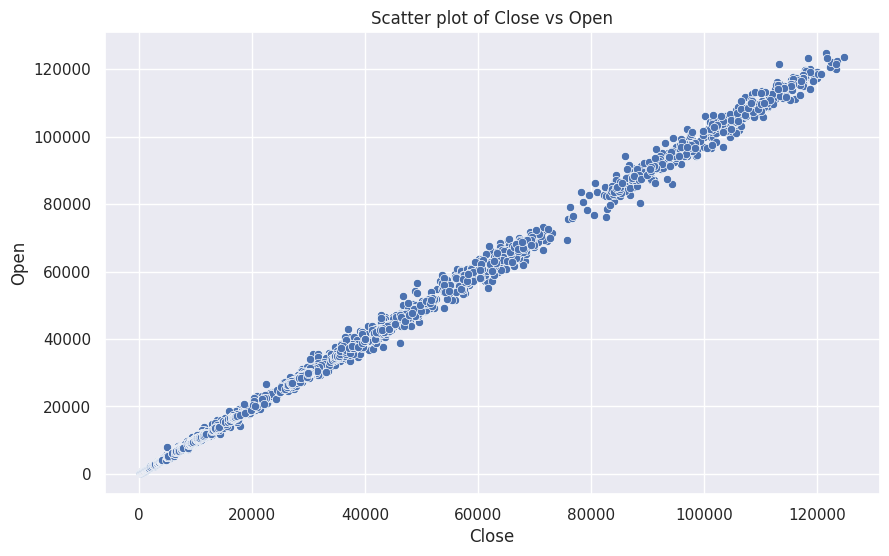

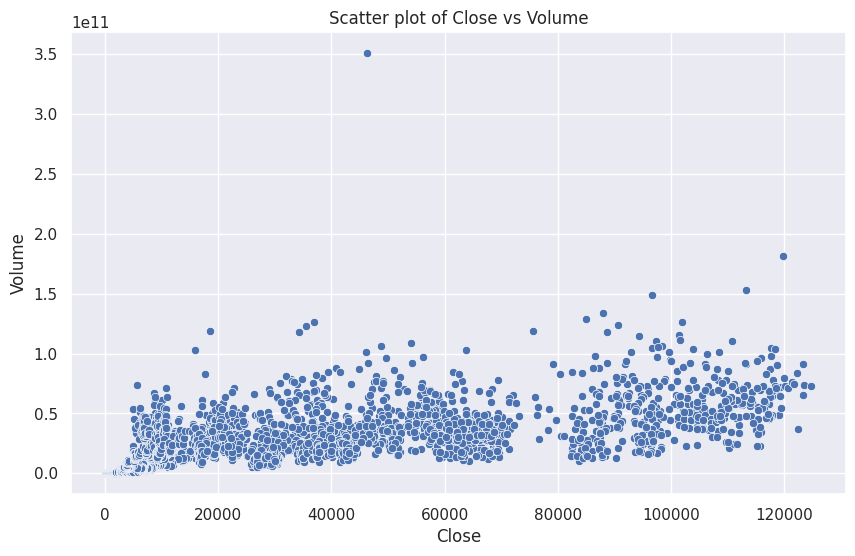

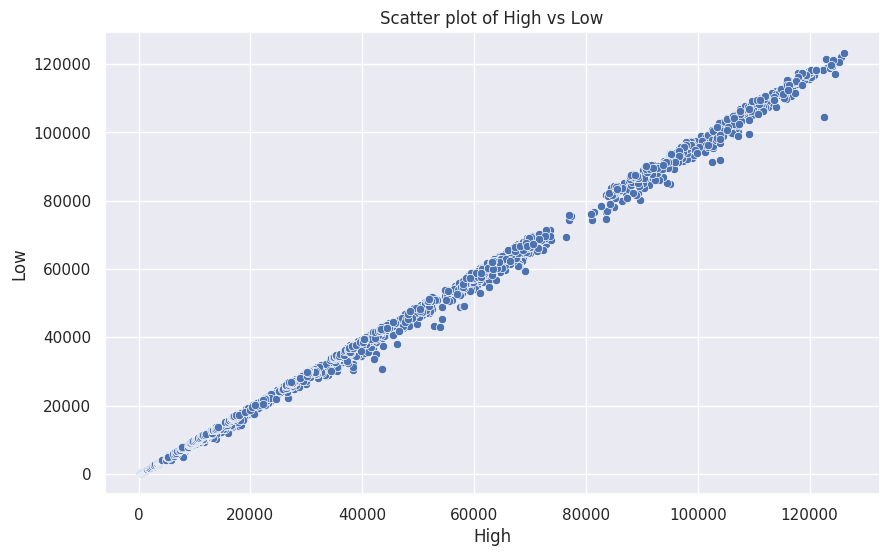

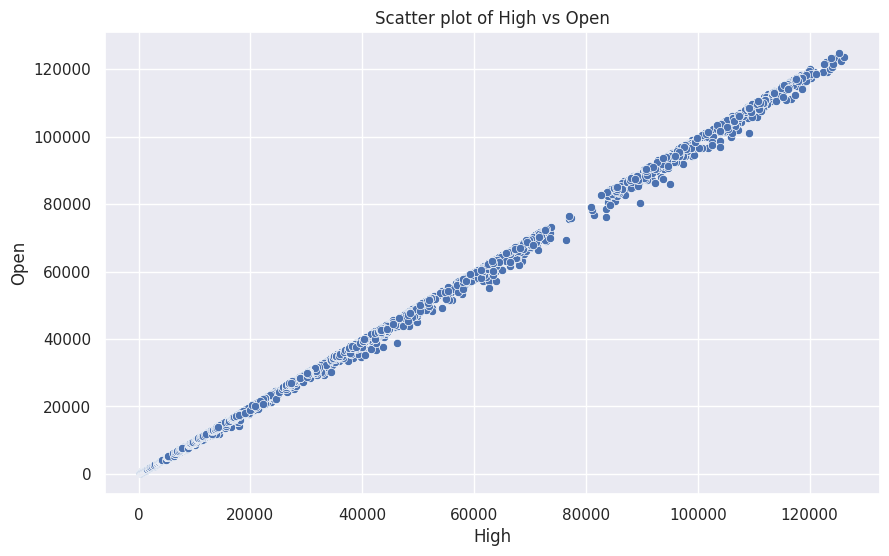

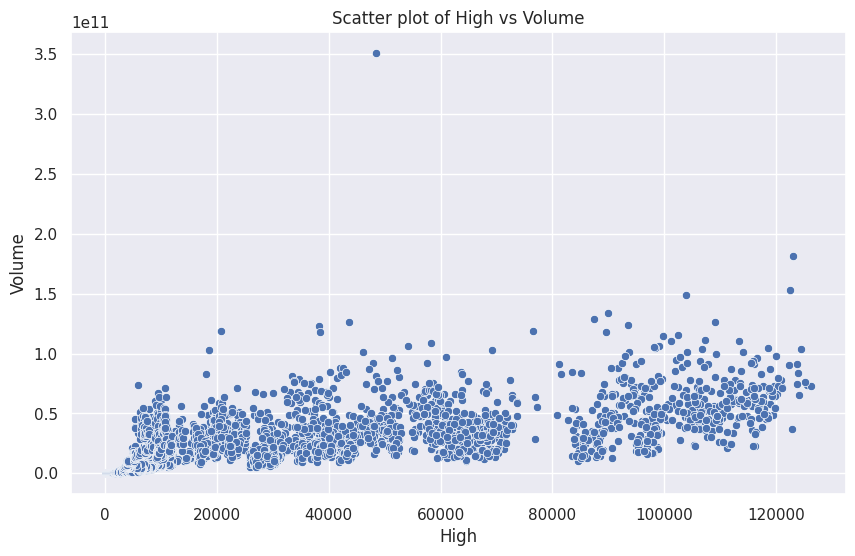

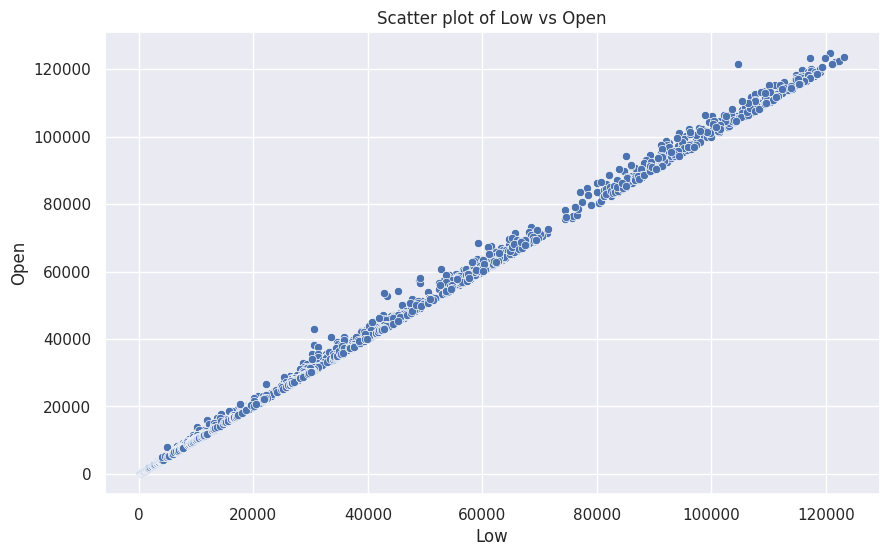

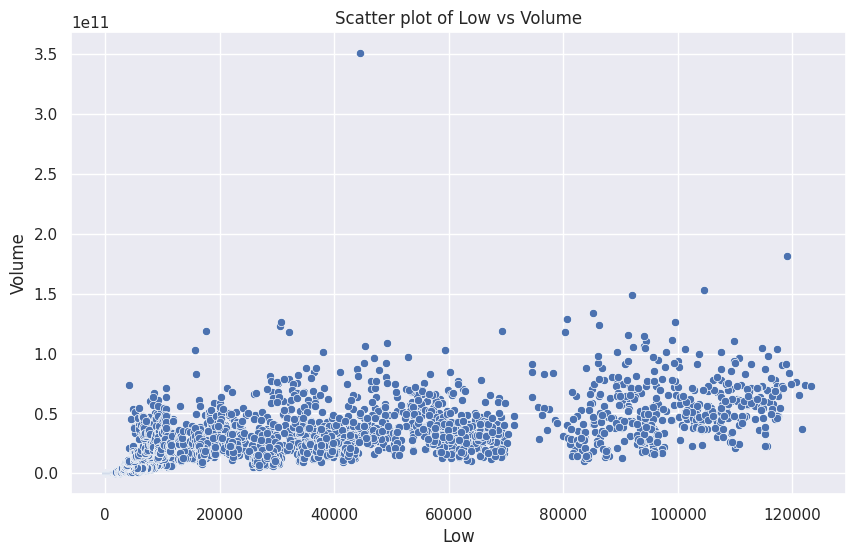

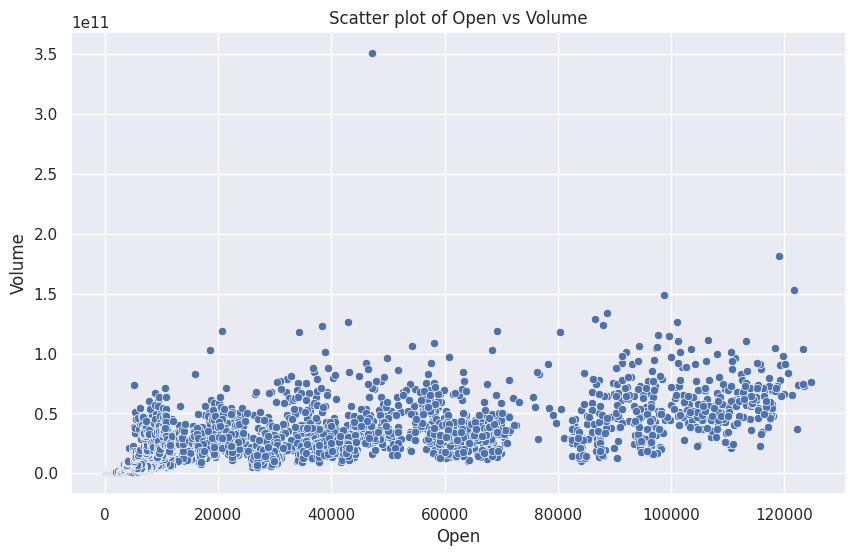

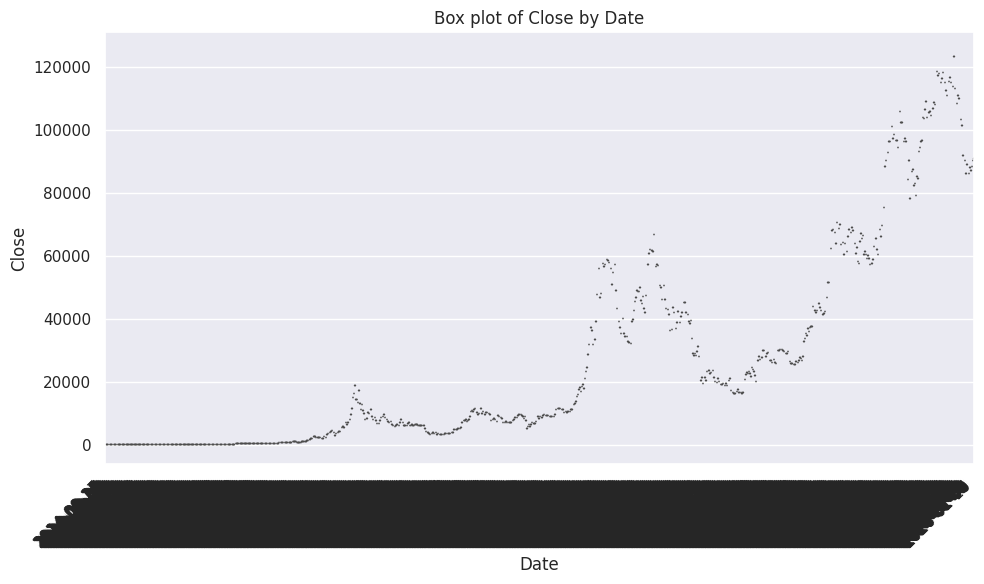

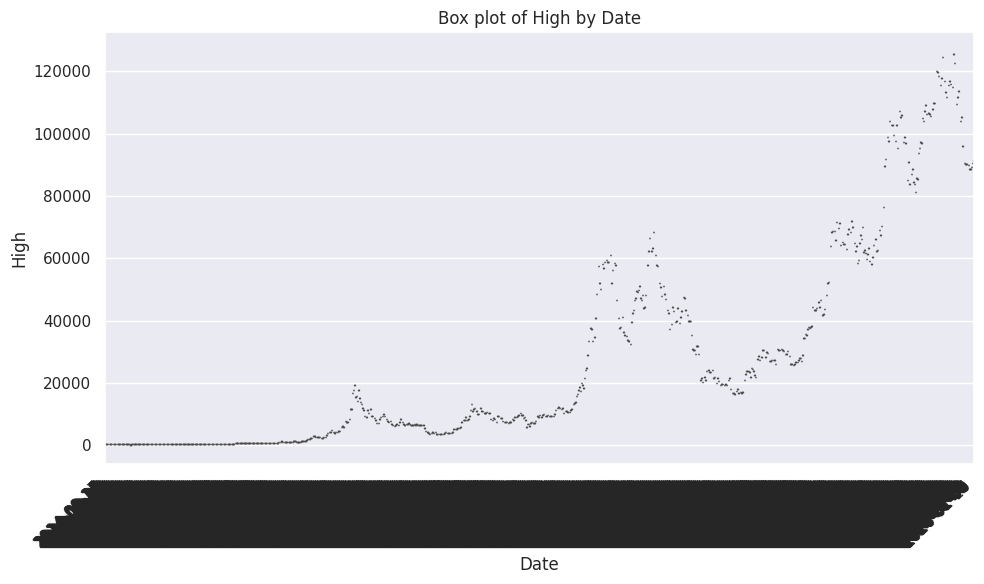

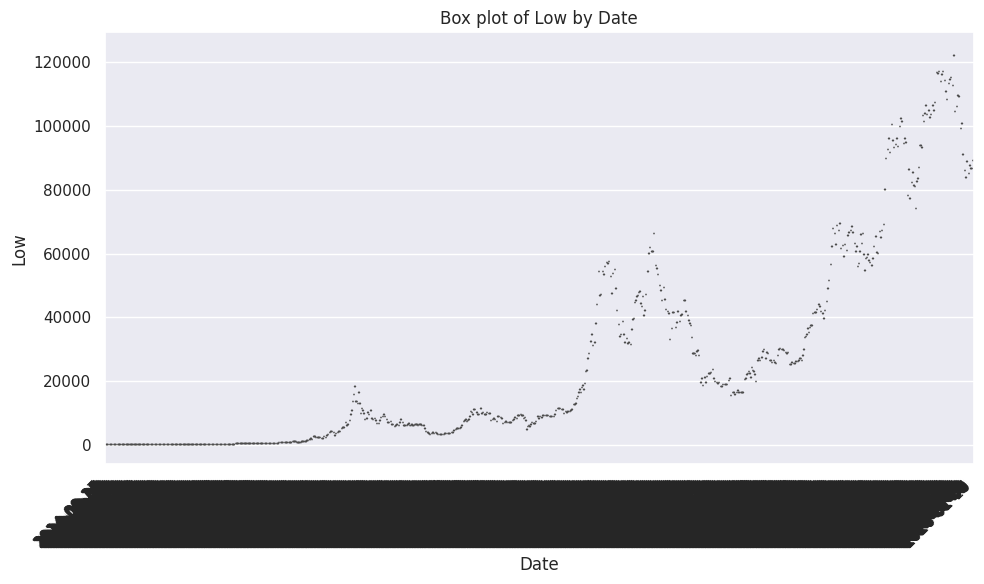

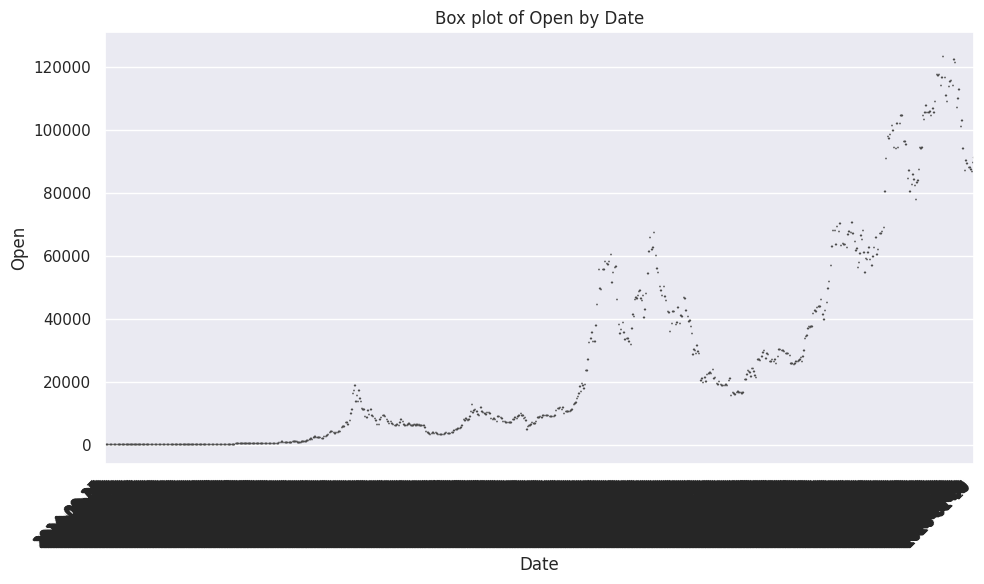

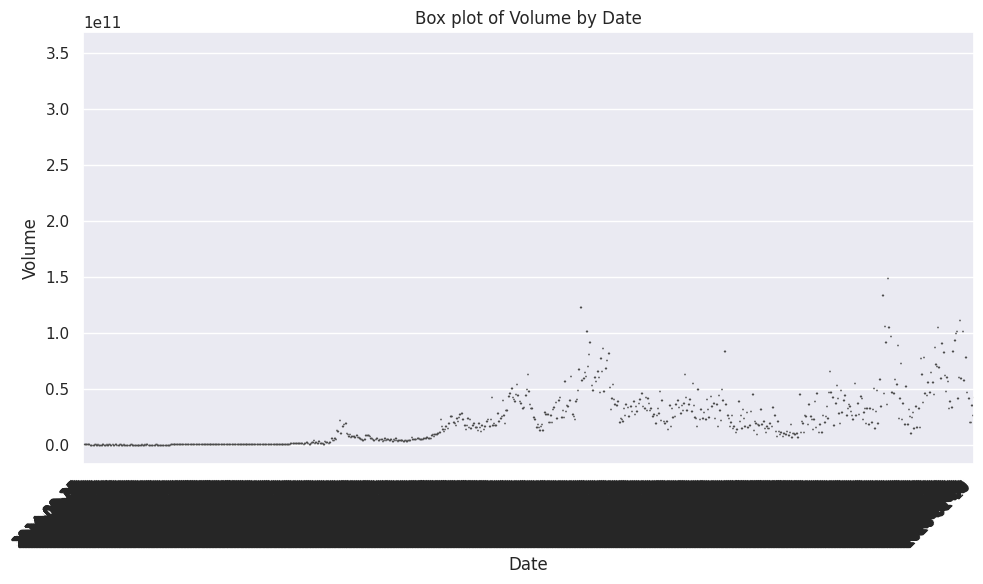

In [20]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

# Pairplot

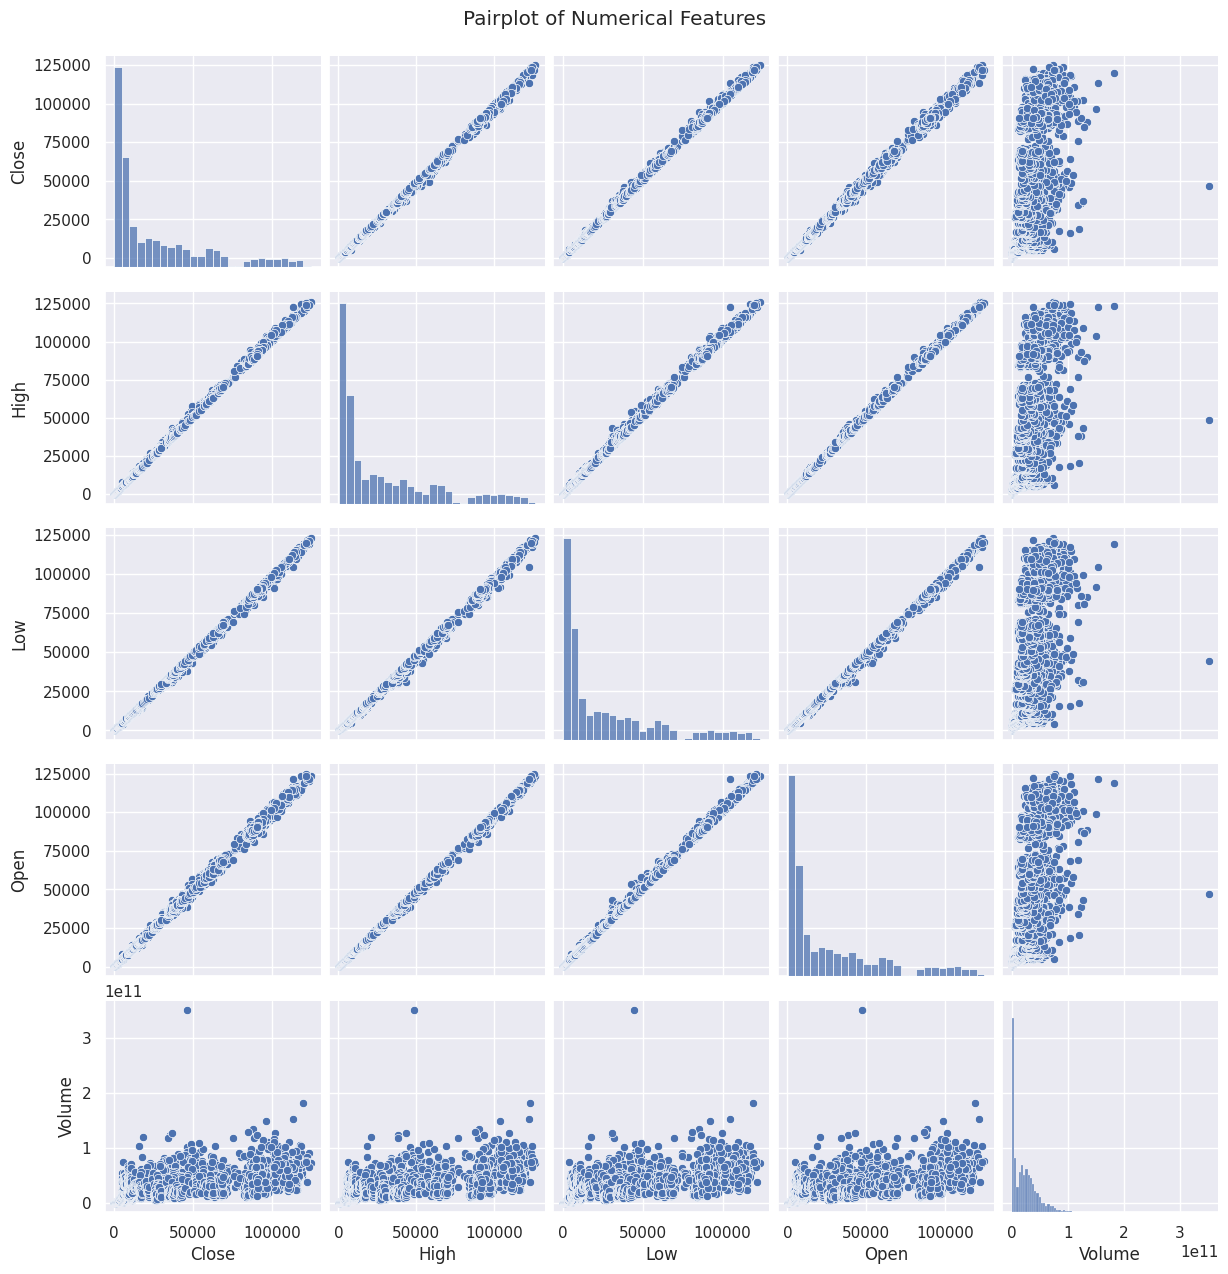

In [21]:
sns.pairplot(df.select_dtypes(include =  np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

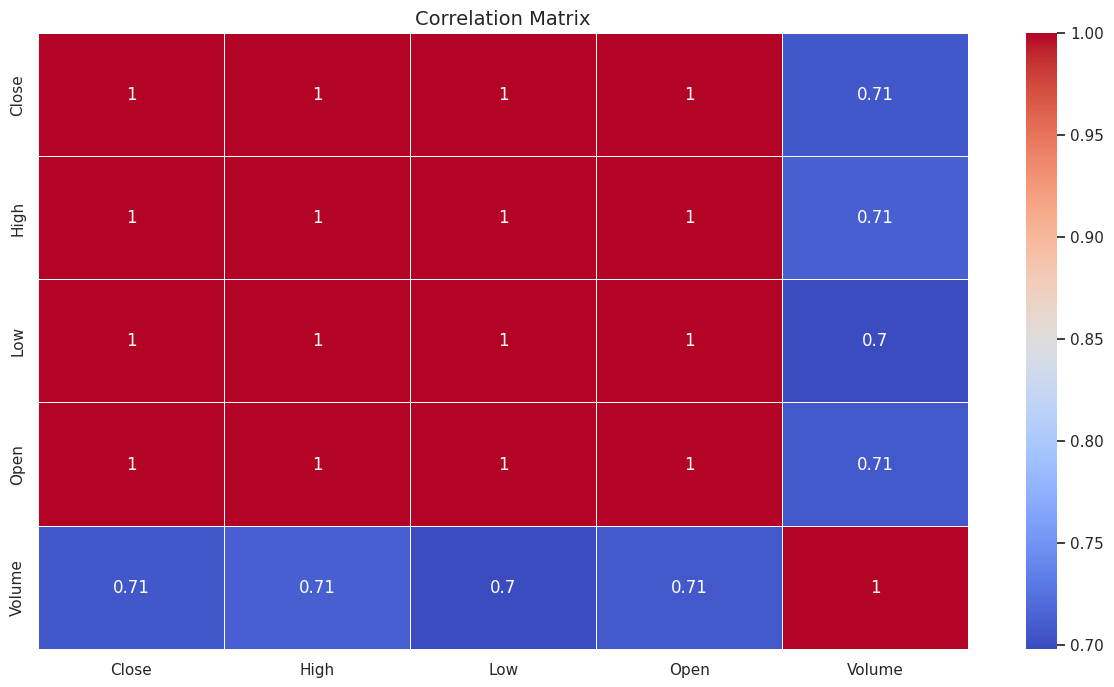

In [22]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

In [29]:
# 1. Create a Copy to avoid warnings
df_trader = df.copy()

# Ensure the data is sorted by Date (Critical for Time-Series)
# df_trader['Date'] = pd.to_datetime(df_trader['Date']) # Uncomment if Date column exists and is not index
# df_trader = df_trader.sort_values('Date')

# --- A. Trend Indicators (Moving Averages) ---
# Traders look for "Crossovers". If SMA_50 crosses above SMA_200, it's a "Golden Cross" (Bullish).
df_trader['SMA_50'] = df_trader['Close'].rolling(window=50).mean()
df_trader['SMA_200'] = df_trader['Close'].rolling(window=200).mean()

# --- B. Momentum Indicators (RSI - Relative Strength Index) ---
# RSI > 70 = Overbought (Sell?), RSI < 30 = Oversold (Buy?)
def calculate_rsi(data, window=14):
    delta = data.diff()
    gain = (delta.where(delta > 0, 0)).fillna(0)
    loss = (-delta.where(delta < 0, 0)).fillna(0)

    # Use Exponential Weighted Moving Average (standard for RSI)
    avg_gain = gain.ewm(com=window-1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window-1, min_periods=window).mean()

    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))

df_trader['RSI'] = calculate_rsi(df_trader['Close'])

# --- C. Volatility Indicators (Bollinger Bands) ---
# Used to measure how "stretched" the price is.
# Formula: 20-day SMA +/- 2 Standard Deviations
df_trader['BB_Middle'] = df_trader['Close'].rolling(window=20).mean()
df_trader['BB_Std'] = df_trader['Close'].rolling(window=20).std()
df_trader['BB_Upper'] = df_trader['BB_Middle'] + (2 * df_trader['BB_Std'])
df_trader['BB_Lower'] = df_trader['BB_Middle'] - (2 * df_trader['BB_Std'])

# --- D. Return & Risk Metrics ---
# Daily Return: Did we make money today?
df_trader['Daily_Return_Pct'] = df_trader['Close'].pct_change() * 100

# Rolling Volatility (30-Day): How risky is the market right now?
df_trader['Volatility_30D'] = df_trader['Daily_Return_Pct'].rolling(window=30).std()

# --- E. Clean Up ---
# Drop NaN values created by the rolling windows (e.g., the first 200 rows for SMA_200)
df_trader.dropna(inplace=True)

# Preview the new "Trader" Dataset
print("New Features Added:")
print(df_trader[['Close', 'SMA_50', 'RSI', 'BB_Upper', 'Volatility_30D']].tail())

New Features Added:
                   Close        SMA_50        RSI      BB_Upper  \
Date                                                              
2026-01-06  93729.031250  89243.983594  64.788191  93084.308360   
2026-01-07  91308.054688  89211.167188  54.686714  93219.003270   
2026-01-08  91027.125000  89202.389844  53.641555  93427.029607   
2026-01-09  90513.101562  89280.013906  51.694775  93552.342474   
2026-01-10  90386.648438  89385.933125  51.202466  93652.263984   

            Volatility_30D  
Date                        
2026-01-06        1.391261  
2026-01-07        1.476309  
2026-01-08        1.415879  
2026-01-09        1.413570  
2026-01-10        1.409409  


# 1. The "Pro-Trader" Dashboard (Candlesticks + Volume)

In [31]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

# 1. Prepare Data
# Use df_trader which contains the calculated SMA_50 and has Date as index
# df_trader was created from df, which had its 'Date' column set as index earlier.

# 2. Create Subplots (Price on Top, Volume on Bottom)
fig = make_subplots(rows=2, cols=1, shared_xaxes=True,
                    vertical_spacing=0.03, subplot_titles=('Bitcoin Price (Candlestick)', 'Volume'),
                    row_width=[0.2, 0.7]) # Top chart is 70% height, Bottom is 20%

# 3. Add Candlestick Chart (Top)
fig.add_trace(go.Candlestick(x=df_trader.index, # Changed to df_trader.index
                open=df_trader['Open'],
                high=df_trader['High'],
                low=df_trader['Low'],
                close=df_trader['Close'],
                name='OHLC'),
                row=1, col=1)

# Add 50-Day Moving Average (Trend Line)
# The SMA_50 is in df_trader, so this condition should now pass and plot the MA.
if 'SMA_50' in df_trader.columns: # Changed to df_trader.columns
    fig.add_trace(go.Scatter(x=df_trader.index, y=df_trader['SMA_50'], mode='lines', marker_color='orange', name='50 Day MA'), row=1, col=1)

# 4. Add Volume Chart (Bottom)
# Color volume bars: Green if Close > Open, Red if Close < Open
colors = ['green' if row['Close'] > row['Open'] else 'red' for index, row in df_trader.iterrows()] # Changed to df_trader
fig.add_trace(go.Bar(x=df_trader.index, y=df_trader['Volume'], marker_color=colors, name='Volume'), row=2, col=1) # Changed to df_trader.index

# 5. Styling
fig.update_layout(
    title='Bitcoin Price Action & Volume Analysis',
    yaxis_title='Price (USD)',
    xaxis_rangeslider_visible=False, # Hides the bottom slider for a cleaner look
    template='plotly_dark' # Dark mode looks more "crypto"
)

fig.show()

# 2. Linear vs. Logarithmic Scale Comparison

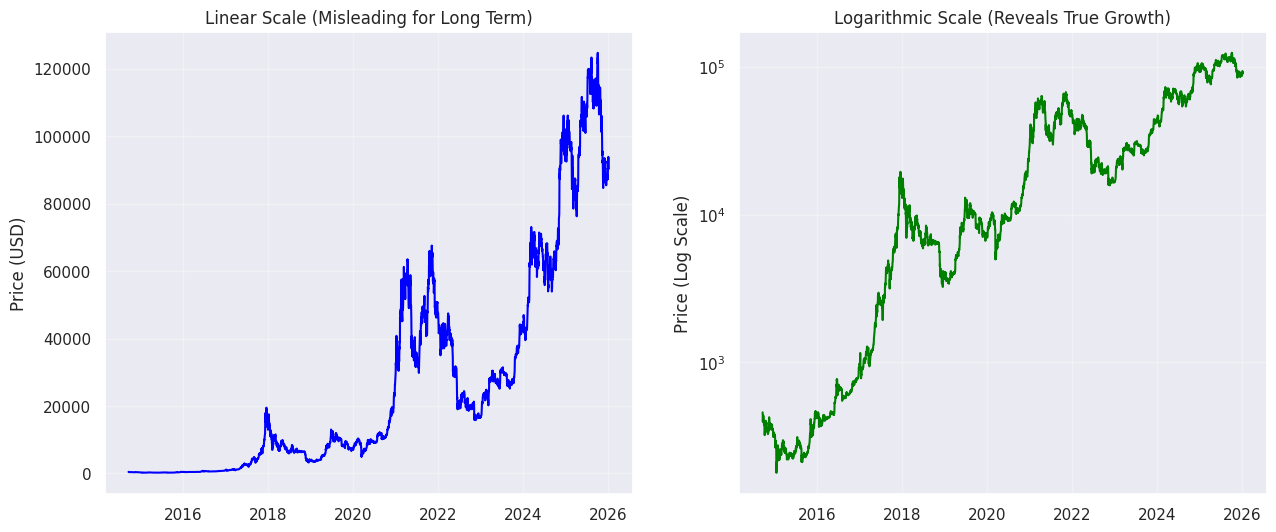

In [33]:
plt.figure(figsize=(15, 6))

# Plot 1: Linear Scale (Standard)
plt.subplot(1, 2, 1)
plt.plot(df_viz.index, df_viz['Close'], color='blue')
plt.title('Linear Scale (Misleading for Long Term)')
plt.ylabel('Price (USD)')
plt.grid(True, alpha=0.3);

# Plot 2: Logarithmic Scale (Correct for Growth Assets)
plt.subplot(1, 2, 2)
plt.plot(df_viz.index, df_viz['Close'], color='green')
plt.yscale('log') # The Magic Line
plt.title('Logarithmic Scale (Reveals True Growth)')
plt.ylabel('Price (Log Scale)')
plt.grid(True, alpha=0.3);

plt.show()

# 3. Seasonal Heatmap (When is the best time to buy?)

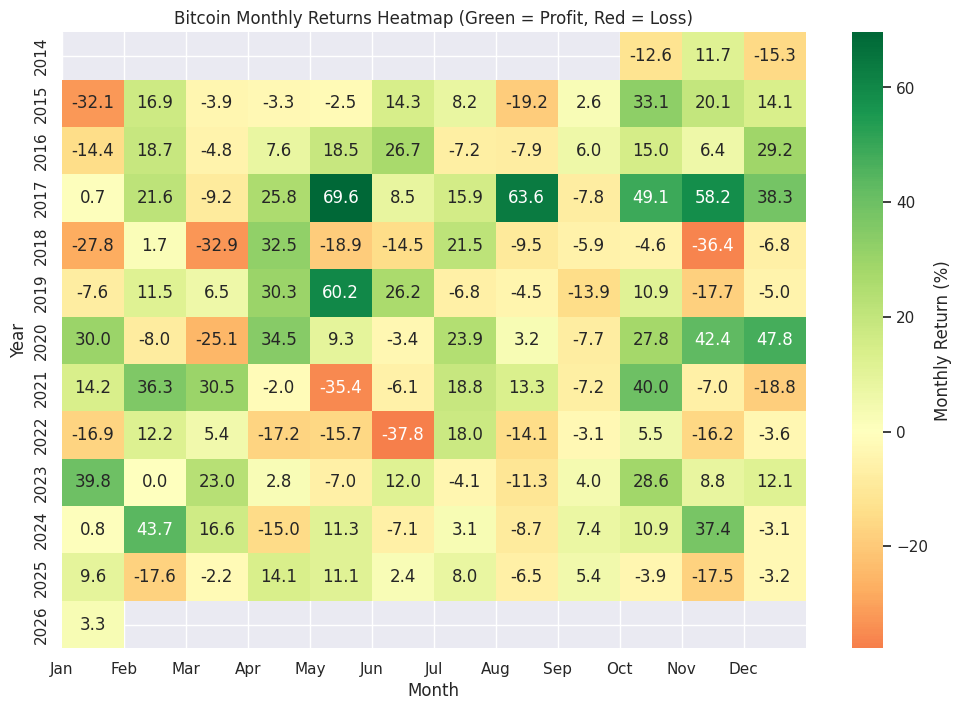

In [35]:
import seaborn as sns

# 1. Extract Month and Year
df_viz['Year'] = df_viz.index.year
df_viz['Month'] = df_viz.index.month_name()

# 2. Calculate Monthly Return (Did we end the month higher or lower?)
# We need to resample to monthly data first
monthly_data = df_viz.resample('M')['Close'].last().pct_change() * 100
monthly_df = monthly_data.to_frame(name='Monthly_Return').reset_index()
monthly_df['Year'] = monthly_df['Date'].dt.year
monthly_df['Month'] = monthly_df['Date'].dt.month

# 3. Pivot for Heatmap
pivot_table = monthly_df.pivot(index='Year', columns='Month', values='Monthly_Return')

# 4. Plot
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='RdYlGn', center=0, annot=True, fmt=".1f", cbar_kws={'label': 'Monthly Return (%)'})
plt.title('Bitcoin Monthly Returns Heatmap (Green = Profit, Red = Loss)')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.show()

Epoch 1/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - loss: 0.0116
Epoch 2/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 4.5366e-04
Epoch 3/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 3.6254e-04
Epoch 4/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 3.6757e-04
Epoch 5/5
128/128 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - loss: 3.0895e-04
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


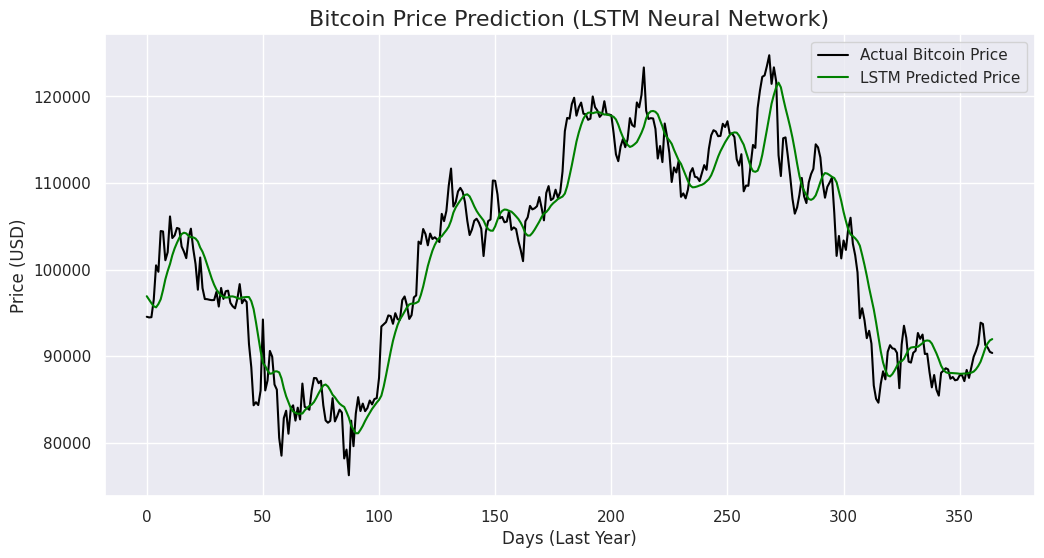

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# 1. Prepare Data
# LSTMs are sensitive to scale, so we scale data between 0 and 1
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

# 2. Create Sequences
# We can't just feed the data in. We need to create "windows".
# e.g., Use Day 1-60 to predict Day 61.
prediction_days = 60

x_train = []
y_train = []

for x in range(prediction_days, len(scaled_data)):
    x_train.append(scaled_data[x-prediction_days:x, 0])
    y_train.append(scaled_data[x, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
# Reshape for LSTM [samples, time steps, features]
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# 3. Build the Neural Network
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(units=50, return_sequences=False))
model.add(Dense(units=25))
model.add(Dense(units=1)) # Prediction of the next closing price

# 4. Train the Model
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=32, epochs=5) # Epochs=5 for speed (use 25+ for better results)

# 5. Test the Model (Predicting the Future)
# Let's verify on the last 365 days of data
test_start = len(scaled_data) - 365 - prediction_days
test_data = scaled_data[test_start:]

x_test = []
actual_prices = df['Close'].values[-365:] # Actual prices for comparison

for x in range(prediction_days, len(test_data)):
    x_test.append(test_data[x-prediction_days:x, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# Make Predictions
predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices) # Undo scaling to get real $ amounts

# 6. Visualize
plt.figure(figsize=(12, 6))
plt.plot(actual_prices, color="black", label="Actual Bitcoin Price")
plt.plot(predicted_prices, color="green", label="LSTM Predicted Price")
plt.title(f"Bitcoin Price Prediction (LSTM Neural Network)", fontsize=16)
plt.xlabel("Days (Last Year)")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

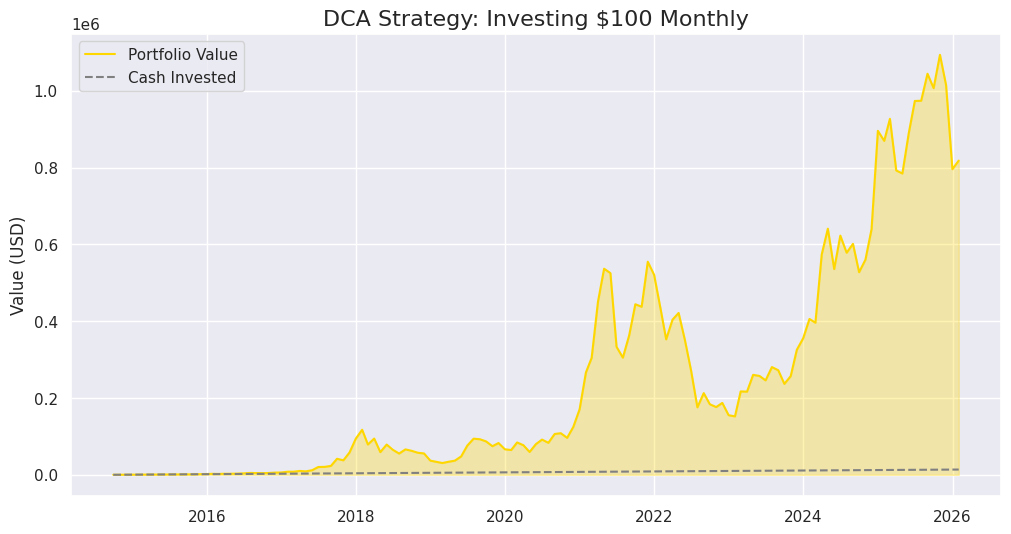

Total Invested: $13,700.00
Final Value:    $818,542.26
Total ROI:      5874.76%


In [38]:
# Create a monthly dataset
df_monthly = df.resample('M')['Close'].first()

investment_per_month = 100
total_invested = 0
total_bitcoin = 0
portfolio_value = []

for price in df_monthly:
    total_invested += investment_per_month
    bitcoin_bought = investment_per_month / price
    total_bitcoin += bitcoin_bought
    portfolio_value.append(total_bitcoin * price)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df_monthly.index, portfolio_value, label='Portfolio Value', color='gold')
plt.plot(df_monthly.index, [investment_per_month * i for i in range(1, len(df_monthly)+1)],
         label='Cash Invested', linestyle='--', color='grey')

plt.title(f'DCA Strategy: Investing ${investment_per_month} Monthly', fontsize=16)
plt.ylabel('Value (USD)')
plt.legend()
plt.fill_between(df_monthly.index, portfolio_value, alpha=0.3, color='gold')
plt.show()

roi = ((portfolio_value[-1] - total_invested) / total_invested) * 100
print(f"Total Invested: ${total_invested:,.2f}")
print(f"Final Value:    ${portfolio_value[-1]:,.2f}")
print(f"Total ROI:      {roi:.2f}%")

# Conclusion Finally

The application of LSTM (Long Short-Term Memory) Neural Networks demonstrated that while short-term price action contains noise, deep learning models can approximate trend directionality by learning from long-term sequential patterns. Ultimately, the data characterizes Bitcoin not just as a speculative vehicle, but as a cyclical asset where long-term time horizon (Buy & Hold) statistically outperforms active technical trading.

# Thank You